# Exploratory Data Analysis — Beyond the Pitch: The Rise of Women's Football

**COM-480 Data Visualization | EPFL | Milestone 1**

This notebook presents an exploratory analysis of women's international football, using three datasets covering match results, individual goalscorers, and penalty shootouts. Our goal is to uncover key patterns and growth trends that will guide our visualization design.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

ACCENT  = '#8B1A4A'   # deep raspberry
ACCENT2 = '#2C5F7C'   # steel blue
ACCENT3 = '#E8A838'   # gold

print('Libraries loaded.')


Libraries loaded.


### Load all three datasets

| File | Content | Rows |
|------|---------|------|
| `results.csv` | Match results (1956–2025) | ~11,000 |
| `goalscorers.csv` | Individual goal records | ~2,800 |
| `shootouts.csv` | Penalty shootout outcomes | ~134 |

We also define contextual data (World Cup summaries, prize money, WSL attendance) inline.

In [2]:
# ============================================================
# Dataset 1: Match results
# ============================================================
df = pd.read_csv('data/results.csv', parse_dates=['date'])

print(f'RESULTS — Shape: {df.shape}')
print(f'Date range: {df.date.min().date()} to {df.date.max().date()}')
print(f'Unique teams: {len(set(df.home_team) | set(df.away_team))}')
print(f'Unique tournaments: {df.tournament.nunique()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head()


RESULTS — Shape: (11177, 9)
Date range: 1956-09-23 to 2025-12-03
Unique teams: 247
Unique tournaments: 117

Missing values:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1956-09-23,Germany,Netherlands,2,1,Friendly,Essen,Germany,False
1,1957-07-28,Germany,England,1,1,Friendly,Stuttgart,Germany,False
2,1957-10-13,Germany,Netherlands,2,0,Friendly,Berlin,Germany,False
3,1957-11-03,Netherlands,Austria,8,1,European Championship,Berlin,Germany,True
4,1957-11-03,Germany,England,0,4,European Championship,Berlin,Germany,False


In [3]:
# ============================================================
# Dataset 2: Goalscorers
# ============================================================
gs = pd.read_csv('data/goalscorers.csv')

print(f'GOALSCORERS — Shape: {gs.shape}')
print(f'Unique scorers: {gs.scorer.nunique()}')
print(f'Penalties: {gs.penalty.sum()} ({gs.penalty.mean()*100:.1f}%)')
print(f'Own goals: {gs.own_goal.sum()} ({gs.own_goal.mean()*100:.1f}%)')
gs.head()


GOALSCORERS — Shape: (2795, 8)
Unique scorers: 1055
Penalties: 212 (7.6%)
Own goals: 82 (2.9%)


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1984-04-08,England,Denmark,England,Linda Curl,31,False,False
1,1984-04-08,England,Denmark,Denmark,Inge Hindkjær,49,False,True
2,1984-04-08,England,Denmark,England,Elisabeth Deighan,51,False,False
3,1984-04-08,Italy,Sweden,Italy,Carolina Morace,18,False,False
4,1984-04-08,Italy,Sweden,Sweden,Helen Johansson,23,False,False


In [4]:
# ============================================================
# Dataset 3: Shootouts
# ============================================================
sh = pd.read_csv('data/shootouts.csv', parse_dates=['date'])

print(f'SHOOTOUTS — Shape: {sh.shape}')
print(f'Date range: {sh.date.min().date()} to {sh.date.max().date()}')
sh.head()


SHOOTOUTS — Shape: (134, 5)
Date range: 1984-05-27 to 2025-12-02


,date,home_team,away_team,winner,first_shooter
0,1984-05-27,England,Sweden,Sweden,NaN
1,1988-06-12,China PR,Brazil,Brazil,Brazil
2,1995-06-13,Sweden,China PR,China PR,China PR
3,1996-05-18,Japan,Canada,Japan,NaN
4,1998-07-25,China PR,Norway,China PR,NaN


In [5]:
# ============================================================
# Contextual data (manually compiled from FIFA / Wikipedia / Deloitte)
# ============================================================
df_wc = pd.DataFrame({
    'year': [1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019, 2023],
    'host': ['China', 'Sweden', 'United States', 'United States', 'China',
             'Germany', 'Canada', 'France', 'Australia / New Zealand'],
    'teams': [12, 12, 16, 16, 16, 16, 24, 24, 32],
    'matches': [26, 26, 32, 32, 32, 32, 52, 52, 64],
    'goals': [99, 99, 123, 107, 111, 86, 146, 146, 164],
    'attendance': [510000, 112213, 1194221, 679664, 997144, 845751, 1353506, 1131312, 1978274],
    'prize_money_usd': [0, 0, 0, 0, 0, 0, 15000000, 30000000, 110000000],
    'winner': ['United States', 'Norway', 'United States', 'Germany', 'Germany',
               'Japan', 'United States', 'United States', 'Spain'],
    'runner_up': ['Norway', 'Germany', 'China PR', 'Sweden', 'Brazil',
                  'United States', 'Japan', 'Netherlands', 'England'],
    'avg_attendance': [19615, 4316, 37319, 21239, 31148, 26428, 26029, 21756, 30905]
})

df_wsl = pd.DataFrame({
    'season': ['2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24', '2024/25'],
    'avg_attendance': [1128, 1518, 980, 2280, 4682, 6610, 5900]
})

df_prize_men = pd.DataFrame({'year': [2002,2006,2010,2014,2018,2022], 'prize_m': [198,254,420,576,791,1000]})
df_prize_women = pd.DataFrame({'year': [1991,1995,1999,2003,2007,2011,2015,2019,2023], 'prize_m': [0,0,0,0,0,0,15,30,110]})

print('Contextual data loaded.')


Contextual data loaded.


In [6]:
# ============================================================
# Preprocessing
# ============================================================
df['year'] = df['date'].dt.year
df['total_goals'] = df['home_score'] + df['away_score']
df['decade'] = (df['year'] // 10) * 10

# Region mapping
region_map = {
    'Europe': ['Germany','Sweden','Norway','England','France','Netherlands','Denmark','Italy',
               'Spain','Switzerland','Finland','Iceland','Scotland','Belgium','Austria','Poland',
               'Czech Republic','Portugal','Russia','Ukraine','Romania','Hungary','Serbia',
               'Croatia','Republic of Ireland','Wales','Greece','Turkey','Belarus','Slovakia',
               'Slovenia','Bosnia and Herzegovina','North Macedonia','Montenegro','Albania',
               'Lithuania','Latvia','Estonia','Luxembourg','Moldova','Georgia','Armenia',
               'Azerbaijan','Kazakhstan','Israel','Cyprus','Malta','Faroe Islands','Kosovo',
               'Bulgaria','Northern Ireland','Liechtenstein','Andorra','San Marino','Gibraltar'],
    'North America': ['United States','Canada','Mexico','Costa Rica','Jamaica',
                      'Trinidad and Tobago','Panama','Haiti','Honduras','Guatemala',
                      'El Salvador','Nicaragua','Cuba','Dominican Republic','Puerto Rico',
                      'Bermuda','Antigua and Barbuda','Saint Kitts and Nevis','Dominica',
                      'Saint Lucia','Barbados','Grenada','Saint Vincent and the Grenadines',
                      'Belize','Guyana','Suriname','Cayman Islands','US Virgin Islands',
                      'Turks and Caicos Islands','Curaçao','Aruba','Anguilla',
                      'British Virgin Islands','Bonaire','Sint Maarten'],
    'South America': ['Brazil','Argentina','Colombia','Chile','Venezuela',
                      'Paraguay','Ecuador','Peru','Uruguay','Bolivia'],
    'Asia': ['Japan','China PR','Korea Republic','Australia','Korea DPR','Thailand',
             'Vietnam','India','Chinese Taipei','Myanmar','Philippines','Uzbekistan',
             'Iran','Jordan','Indonesia','Malaysia','Hong Kong','Singapore','Bahrain',
             'Iraq','Palestine','Lebanon','Saudi Arabia','United Arab Emirates','Oman',
             'Qatar','Kuwait','Yemen','Syria','Afghanistan','Turkmenistan','Tajikistan',
             'Kyrgyzstan','Maldives','Nepal','Bhutan','Sri Lanka','Bangladesh','Pakistan',
             'Mongolia','Guam','Laos','Cambodia','Macau','Brunei','Timor-Leste'],
    'Africa': ['Nigeria','Cameroon','South Africa','Ghana',"Côte d'Ivoire",'Morocco',
               'Senegal','Kenya','Tanzania','Zambia','DR Congo','Tunisia','Algeria',
               'Mali','Ethiopia','Burkina Faso','Guinea','Benin','Togo','Sierra Leone',
               'Liberia','Niger','Gabon','Congo','Equatorial Guinea','Mozambique',
               'Zimbabwe','Malawi','Uganda','Rwanda','Burundi','Namibia','Botswana',
               'Madagascar','Mauritius','Cape Verde','São Tomé and Príncipe','Comoros',
               'Eswatini','Lesotho','Gambia','Mauritania','Central African Republic',
               'Chad','Djibouti','Eritrea','Libya','Somalia','South Sudan','Sudan','Angola',
               'Seychelles'],
    'Oceania': ['New Zealand','Papua New Guinea','Fiji','Samoa','Tonga','Solomon Islands',
                'Vanuatu','New Caledonia','Tahiti','Cook Islands','American Samoa']
}

country_to_region = {}
for region, countries in region_map.items():
    for c in countries:
        country_to_region[c] = region

df['home_region'] = df['home_team'].map(country_to_region)
df['away_region'] = df['away_team'].map(country_to_region)

unmapped = sorted(set(t for t in (set(df.home_team) | set(df.away_team)) if t not in country_to_region))
if unmapped:
    print(f'⚠ {len(unmapped)} unmapped teams (add to region_map if needed):')
    for t in unmapped:
        print(f'  - {t}')
else:
    print('✓ All teams mapped to regions.')

print(f'\n✓ Preprocessing complete. {len(df):,} matches ready.')


⚠ 49 unmapped teams (add to region_map if needed):
  - Bahamas
  - Catalonia
  - Curacao
  - Czechoslovakia
  - Egypt
  - FR Yugoslavia
  - Froya
  - Gotland
  - Gozo
  - Great Britain
  - Greenland
  - Guadeloupe
  - Guernsey
  - Guinea-Bissau
  - Hitra
  - Isle of Man
  - Isle of Wight
  - Ivory Coast
  - Jersey
  - Kiribati
  - Macedonia
  - Martinique
  - Mayotte
  - Menorca
  - Netherlands Antilles
  - North Korea
  - Northern Mariana Islands
  - Orkney
  - Prince Edward Island
  - Rhodes
  - Réunion
  - Saare County
  - Serbia and Montenegro
  - Shetland
  - Shetland Islands
  - South Korea
  - Surrey
  - Székely Land
  - Sápmi
  - Taiwan
  - Tamil Eelam
  - Tibet
  - U.S. Virgin Islands
  - United States Virgin Islands
  - Western Isles
  - Ynys Môn
  - Yugoslavia
  - Zanzibar
  - Åland

✓ Preprocessing complete. 11,177 matches ready.


---
## 2. The Growth of Women's Football

Our first question: **how has the volume of women's international football changed over time?**

### 2.1 Matches Per Year

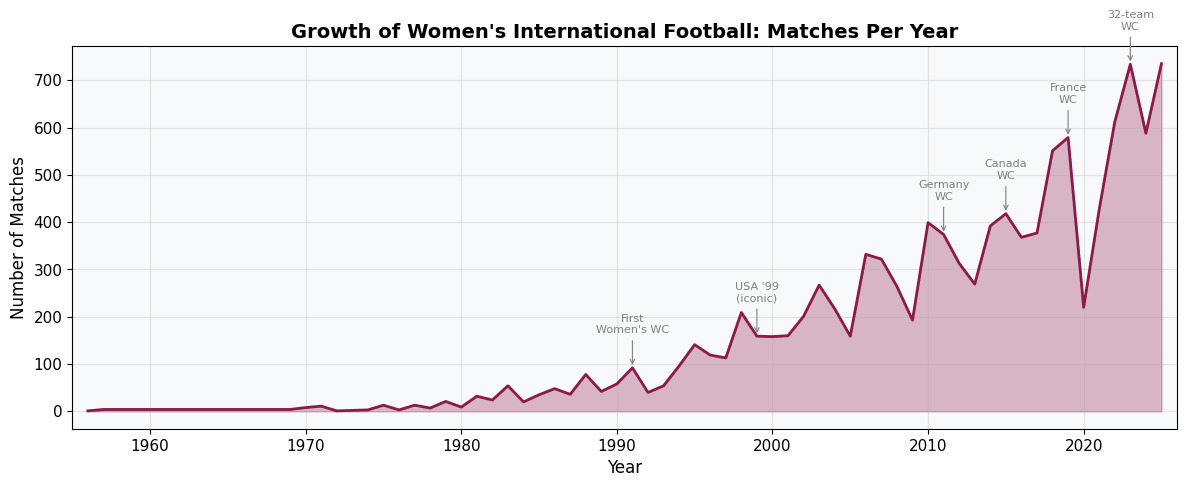

Peak: 2025 with 735 matches
2020 (COVID): 220 matches


In [7]:
matches_per_year = df.groupby('year').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(matches_per_year.index, matches_per_year.values, alpha=0.3, color=ACCENT)
ax.plot(matches_per_year.index, matches_per_year.values, color=ACCENT, linewidth=2)

events = {1991: 'First\nWomen\'s WC', 1999: 'USA \'99\n(iconic)',
          2011: 'Germany\nWC', 2015: 'Canada\nWC', 2019: 'France\nWC', 2023: '32-team\nWC'}
for yr, label in events.items():
    if yr in matches_per_year.index:
        ax.annotate(label, xy=(yr, matches_per_year[yr]), xytext=(0, 25),
                    textcoords='offset points', ha='center', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8), color='gray')

ax.set_title('Growth of Women\'s International Football: Matches Per Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Matches')
ax.set_xlim(df.year.min() - 1, df.year.max() + 1)
plt.tight_layout()
plt.show()

print(f'Peak: {matches_per_year.idxmax()} with {matches_per_year.max()} matches')
print(f'2020 (COVID): {matches_per_year.get(2020, "N/A")} matches')


### 2.2 Number of Active Nations Per Year

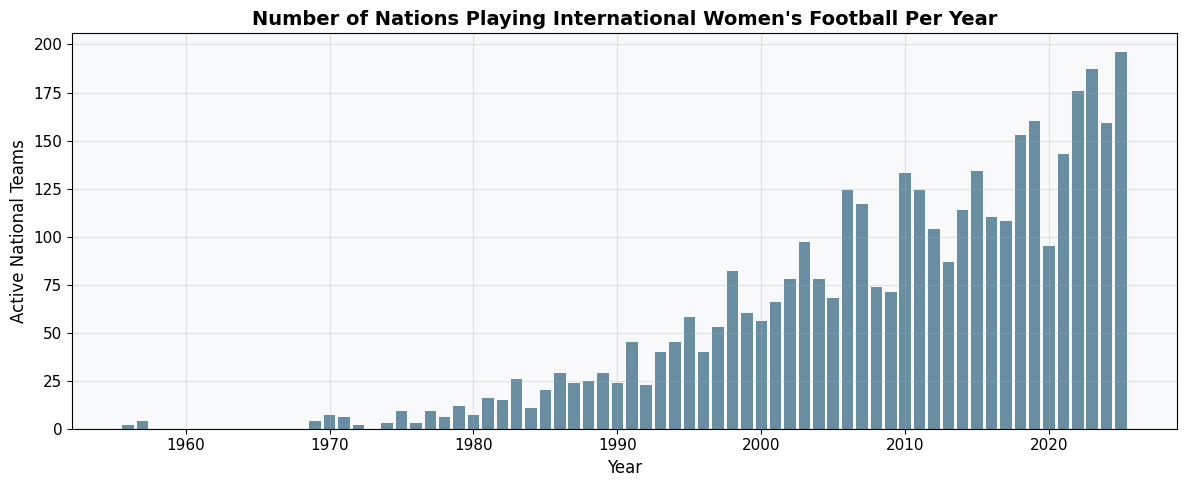

Peak: 2025 with 196 active teams


In [8]:
def count_active(year):
    yr = df[df.year == year]
    return len(set(yr.home_team) | set(yr.away_team))

years = range(df.year.min(), df.year.max() + 1)
active = pd.Series([count_active(y) for y in years], index=years)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(active.index, active.values, color=ACCENT2, alpha=0.7, width=0.8)
ax.set_title('Number of Nations Playing International Women\'s Football Per Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Active National Teams')
plt.tight_layout()
plt.show()

print(f'Peak: {active.idxmax()} with {active.max()} active teams')


**Key insight:** From a handful of teams in the 1960s–70s to **200+ nations** in recent years. The geographic spread of the game is one of the most remarkable changes in world football. This expansion will be a central visual in our project.

---
## 3. How the Game Has Changed

### 3.1 Declining Goals Per Match = Rising Competitiveness

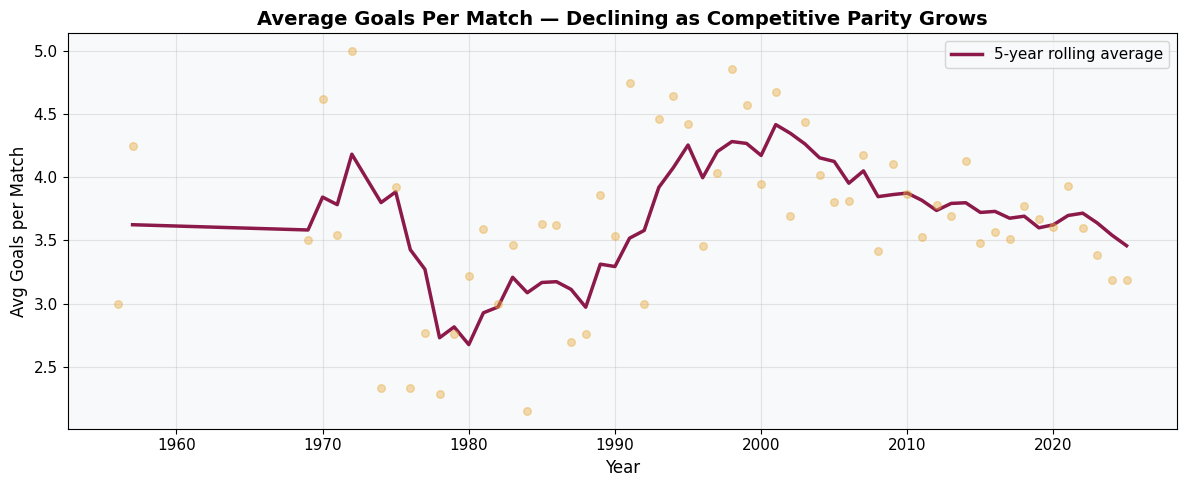

Early era (pre-1996): 3.47 goals/match
Recent era (2015+):   3.54 goals/match
Decline: 1.9%


In [9]:
goals_by_year = df.groupby('year')['total_goals'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(goals_by_year.index, goals_by_year.values, alpha=0.4, color=ACCENT3, s=30, zorder=3)
rolling = goals_by_year.rolling(5, min_periods=2).mean()
ax.plot(rolling.index, rolling.values, color=ACCENT, linewidth=2.5, label='5-year rolling average')
ax.set_title('Average Goals Per Match — Declining as Competitive Parity Grows', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Goals per Match')
ax.legend()
plt.tight_layout()
plt.show()

early = goals_by_year[goals_by_year.index <= 1995].mean()
recent = goals_by_year[goals_by_year.index >= 2015].mean()
print(f'Early era (pre-1996): {early:.2f} goals/match')
print(f'Recent era (2015+):   {recent:.2f} goals/match')
print(f'Decline: {((recent-early)/early)*100:.1f}%')


### 3.2 Match Outcomes Over Time

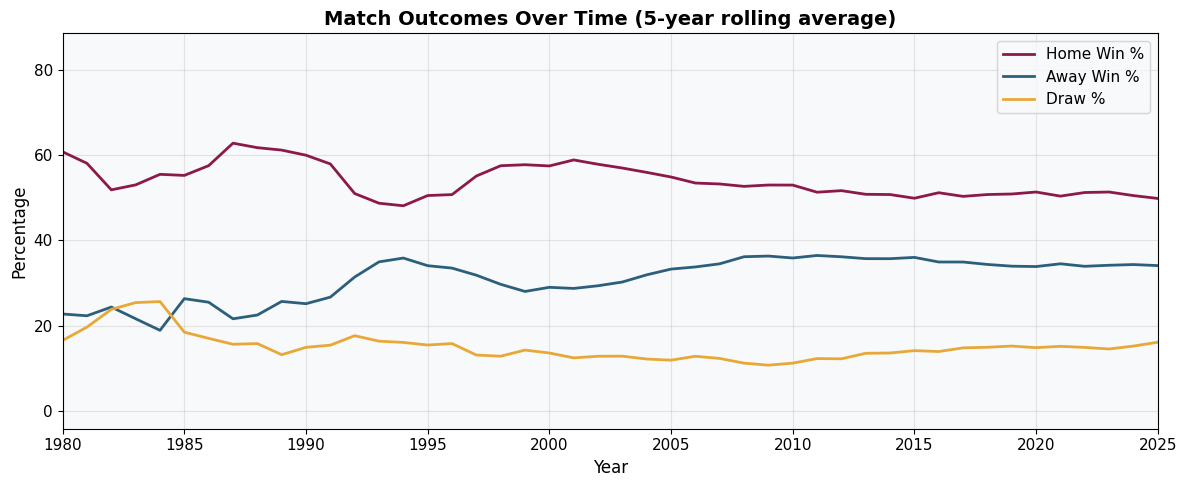

In [10]:
df['result'] = np.where(df.home_score > df.away_score, 'Home Win',
                np.where(df.home_score < df.away_score, 'Away Win', 'Draw'))

result_by_year = df.groupby(['year', 'result']).size().unstack(fill_value=0)
result_pct = result_by_year.div(result_by_year.sum(axis=1), axis=0) * 100
result_rolling = result_pct.rolling(5, min_periods=2).mean()

fig, ax = plt.subplots(figsize=(12, 5))
for col, color, label in [('Home Win', ACCENT, 'Home Win %'),
                           ('Away Win', ACCENT2, 'Away Win %'),
                           ('Draw', ACCENT3, 'Draw %')]:
    if col in result_rolling.columns:
        ax.plot(result_rolling.index, result_rolling[col], color=color, linewidth=2, label=label)

ax.set_title('Match Outcomes Over Time (5-year rolling average)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage')
ax.legend()
ax.set_xlim(1980, df.year.max())
plt.tight_layout()
plt.show()


### 3.3 Goal Scoring Patterns

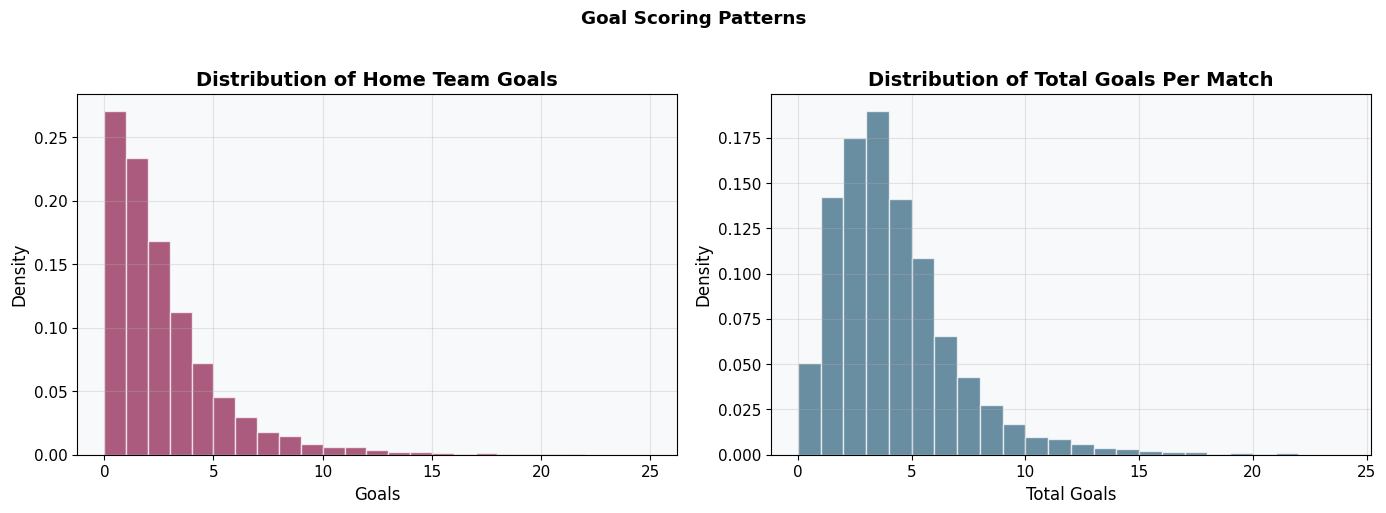

Median total goals: 3
Mean total goals:   3.72
Max in single match: 26
  → Cameroon 2-24 South Africa (2006-11-10)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['home_score'], bins=range(0, int(df.home_score.max())+2),
             color=ACCENT, alpha=0.7, edgecolor='white', density=True)
axes[0].set_title('Distribution of Home Team Goals', fontweight='bold')
axes[0].set_xlabel('Goals'); axes[0].set_ylabel('Density')

axes[1].hist(df['total_goals'], bins=range(0, min(int(df.total_goals.max())+2, 25)),
             color=ACCENT2, alpha=0.7, edgecolor='white', density=True)
axes[1].set_title('Distribution of Total Goals Per Match', fontweight='bold')
axes[1].set_xlabel('Total Goals'); axes[1].set_ylabel('Density')

plt.suptitle('Goal Scoring Patterns', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Median total goals: {df.total_goals.median():.0f}')
print(f'Mean total goals:   {df.total_goals.mean():.2f}')
print(f'Max in single match: {df.total_goals.max():.0f}')
biggest = df.loc[df.total_goals.idxmax()]
print(f'  → {biggest.home_team} {biggest.home_score}-{biggest.away_score} {biggest.away_team} ({biggest.date.date()})')


---
## 4. Who Dominates? Geographic Analysis

### 4.1 Top 15 Winningest Nations

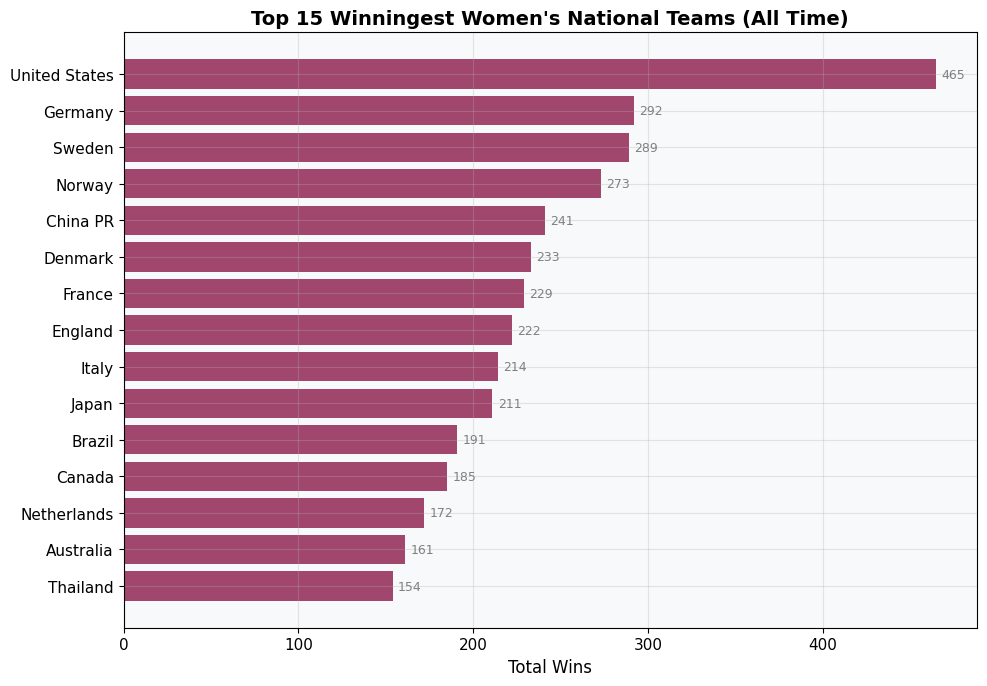

In [12]:
home_wins = df[df.home_score > df.away_score].groupby('home_team').size()
away_wins = df[df.away_score > df.home_score].groupby('away_team').size()
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=True)
top15 = total_wins.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15.index, top15.values, color=ACCENT, alpha=0.8)
for i, (country, wins) in enumerate(top15.items()):
    ax.text(wins + 3, i, str(int(wins)), va='center', fontsize=9, color='gray')

ax.set_title('Top 15 Winningest Women\'s National Teams (All Time)', fontweight='bold')
ax.set_xlabel('Total Wins')
plt.tight_layout()
plt.show()


### 4.2 Regional Dominance Over Decades

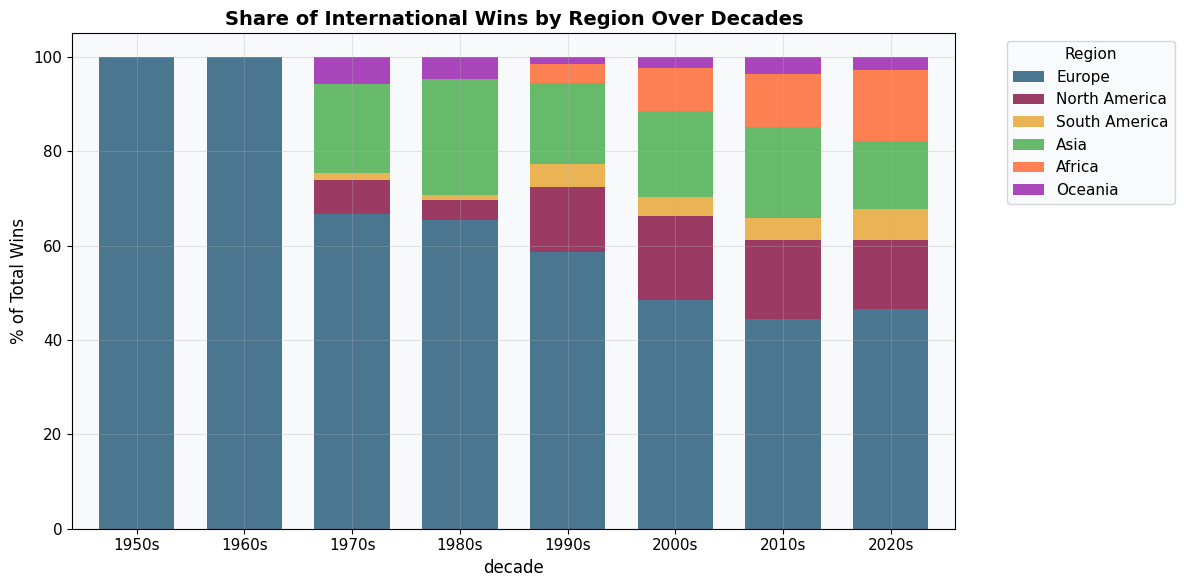

In [13]:
home_w = df[df.home_score > df.away_score][['decade','home_region']].rename(columns={'home_region':'region'})
away_w = df[df.away_score > df.home_score][['decade','away_region']].rename(columns={'away_region':'region'})
all_wins = pd.concat([home_w, away_w]).dropna()

region_decade = all_wins.groupby(['decade','region']).size().unstack(fill_value=0)
region_pct = region_decade.div(region_decade.sum(axis=1), axis=0) * 100

col_order = [c for c in ['Europe','North America','South America','Asia','Africa','Oceania'] if c in region_pct.columns]
region_pct = region_pct[col_order]

colors = {'Europe':'#2C5F7C', 'North America':'#8B1A4A', 'South America':'#E8A838',
          'Asia':'#4CAF50', 'Africa':'#FF6B35', 'Oceania':'#9C27B0'}

fig, ax = plt.subplots(figsize=(12, 6))
region_pct.plot(kind='bar', stacked=True, ax=ax,
                color=[colors.get(c,'gray') for c in region_pct.columns], alpha=0.85, width=0.7)
ax.set_title('Share of International Wins by Region Over Decades', fontweight='bold')
ax.set_ylabel('% of Total Wins')
ax.set_xticklabels([f'{int(d)}s' for d in region_pct.index], rotation=0)
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Key insight:** Europe and North America have historically dominated, but Asia (Japan, China, South Korea) and South America (Brazil) have become increasingly competitive. Africa's share is growing — an important story for our visualization.

### 4.3 Tournament Distribution

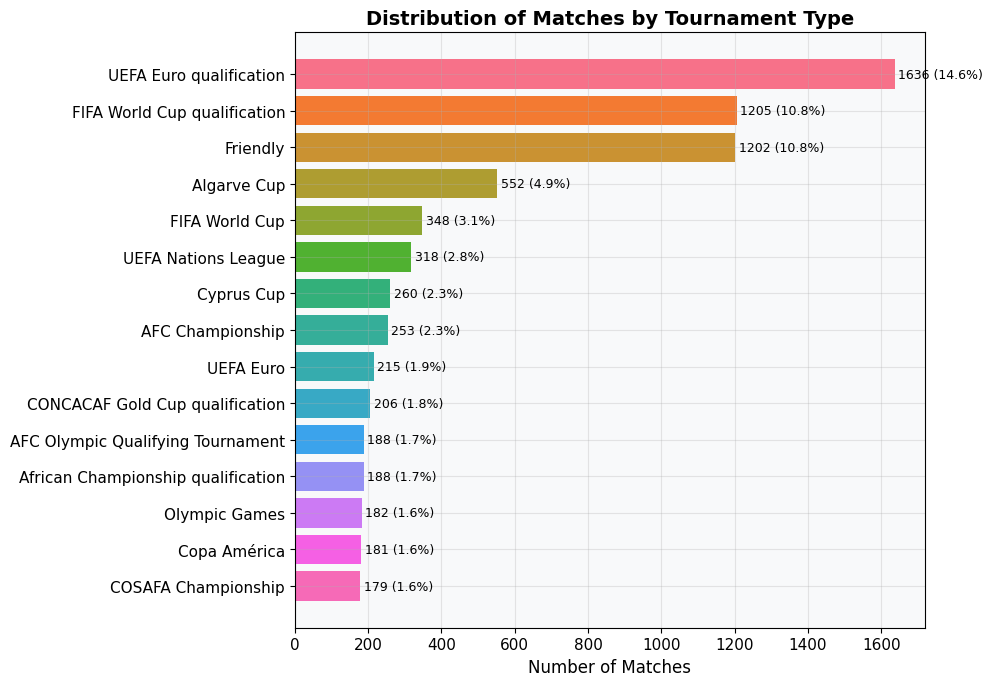

In [14]:
tourn_counts = df['tournament'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("husl", len(tourn_counts))
ax.barh(tourn_counts.index[::-1], tourn_counts.values[::-1], color=palette[::-1])
for i, v in enumerate(tourn_counts.values[::-1]):
    ax.text(v + 10, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_title('Distribution of Matches by Tournament Type', fontweight='bold')
ax.set_xlabel('Number of Matches')
plt.tight_layout()
plt.show()


---
## 5. Individual Goalscorers Analysis

This is where we go beyond match results and explore **who** scores the goals — made possible by the `goalscorers.csv` dataset with ~2,800 individual goal records.

### 5.1 Top 15 All-Time Goalscorers

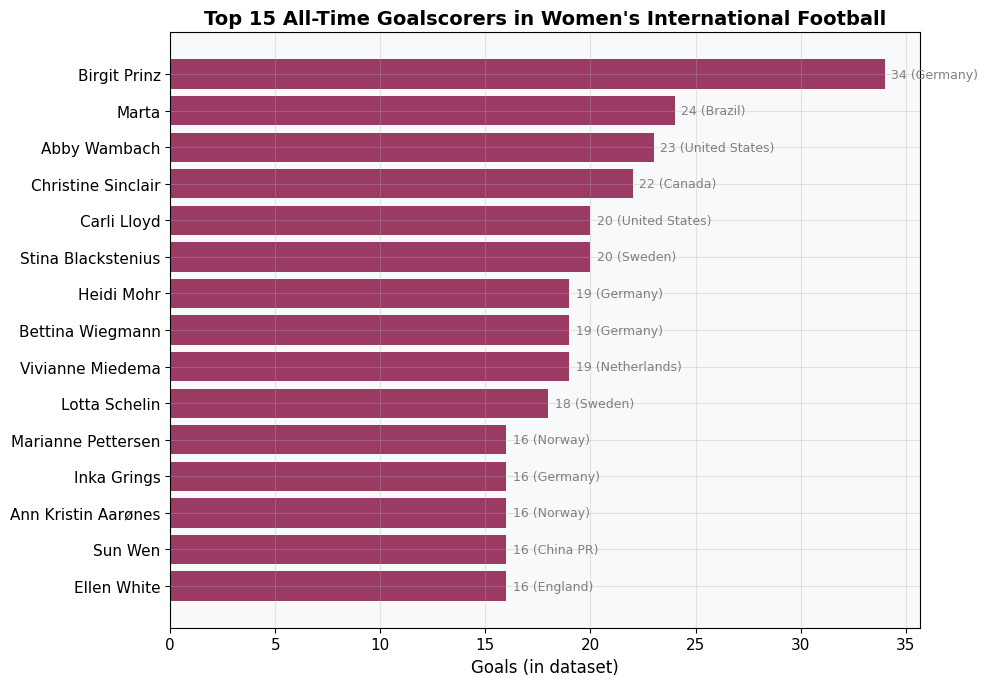

Total goals recorded: 2,713
Unique scorers: 995


In [15]:
# Exclude own goals
goals_clean = gs[gs.own_goal == False]
top_scorers = goals_clean.groupby('scorer').size().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_scorers.index[::-1], top_scorers.values[::-1], color=ACCENT, alpha=0.85)

# Add team info
scorer_teams = goals_clean.groupby('scorer')['team'].agg(lambda x: x.mode()[0])
for i, (scorer, goals) in enumerate(zip(top_scorers.index[::-1], top_scorers.values[::-1])):
    team = scorer_teams.get(scorer, '')
    ax.text(goals + 0.3, i, f'{goals} ({team})', va='center', fontsize=9, color='gray')

ax.set_title('Top 15 All-Time Goalscorers in Women\'s International Football', fontweight='bold')
ax.set_xlabel('Goals (in dataset)')
plt.tight_layout()
plt.show()

print(f'Total goals recorded: {len(goals_clean):,}')
print(f'Unique scorers: {goals_clean.scorer.nunique():,}')


### 5.2 When Do Goals Happen? Minute-by-Minute Analysis

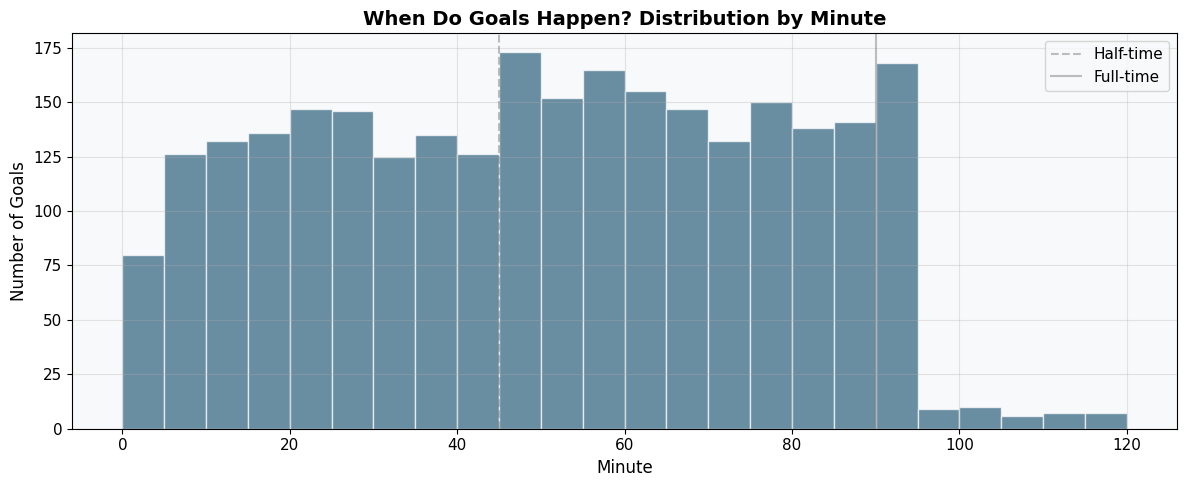

1st half goals: 1217 (44.9%)
2nd half goals: 1455 (53.6%)
Extra time:     41 (1.5%)


In [16]:
# Filter valid minutes
goals_with_min = goals_clean[goals_clean['minute'].notna() & (goals_clean['minute'] > 0)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(goals_with_min['minute'], bins=range(0, 125, 5), color=ACCENT2, alpha=0.7, edgecolor='white')
ax.axvline(x=45, color='gray', linestyle='--', alpha=0.5, label='Half-time')
ax.axvline(x=90, color='gray', linestyle='-', alpha=0.5, label='Full-time')
ax.set_title('When Do Goals Happen? Distribution by Minute', fontweight='bold')
ax.set_xlabel('Minute')
ax.set_ylabel('Number of Goals')
ax.legend()
plt.tight_layout()
plt.show()

first_half = goals_with_min[goals_with_min.minute <= 45]
second_half = goals_with_min[(goals_with_min.minute > 45) & (goals_with_min.minute <= 90)]
extra = goals_with_min[goals_with_min.minute > 90]
print(f'1st half goals: {len(first_half)} ({len(first_half)/len(goals_with_min)*100:.1f}%)')
print(f'2nd half goals: {len(second_half)} ({len(second_half)/len(goals_with_min)*100:.1f}%)')
print(f'Extra time:     {len(extra)} ({len(extra)/len(goals_with_min)*100:.1f}%)')


### 5.3 Penalties and Own Goals

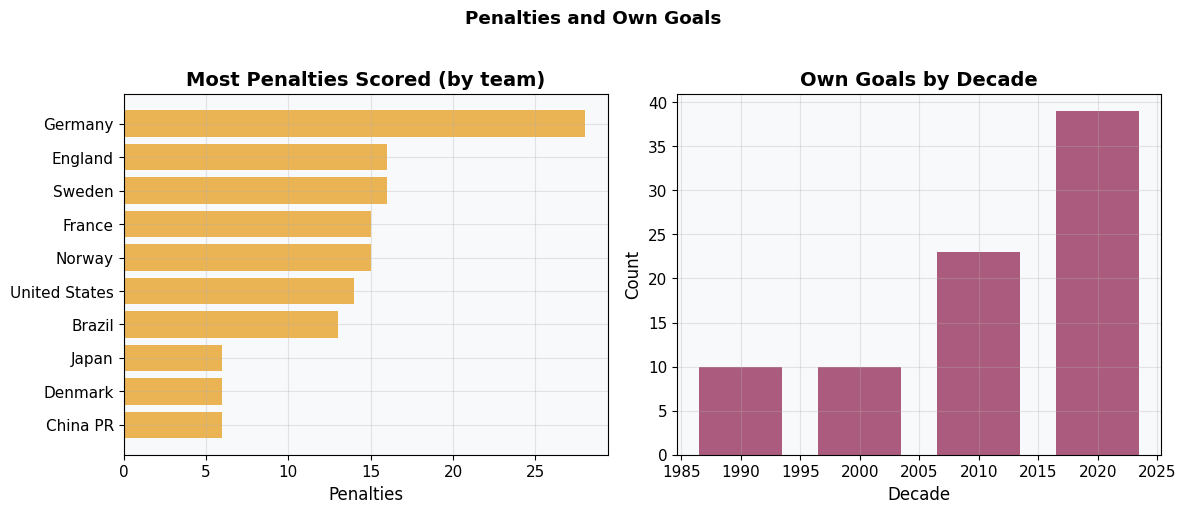

Total penalties: 212 (7.6% of all goals)
Total own goals: 82 (2.9% of all goals)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Penalties by team
pen = goals_clean[goals_clean.penalty == True]
pen_by_team = pen.groupby('team').size().sort_values(ascending=False).head(10)

axes[0].barh(pen_by_team.index[::-1], pen_by_team.values[::-1], color=ACCENT3, alpha=0.85)
axes[0].set_title('Most Penalties Scored (by team)', fontweight='bold')
axes[0].set_xlabel('Penalties')

# Own goals over decades
og = gs[gs.own_goal == True].copy()
og['date'] = pd.to_datetime(og['date'])
og['decade'] = (og['date'].dt.year // 10) * 10
og_decade = og.groupby('decade').size()

axes[1].bar(og_decade.index, og_decade.values, color=ACCENT, alpha=0.7, width=7)
axes[1].set_title('Own Goals by Decade', fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Count')

plt.suptitle('Penalties and Own Goals', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total penalties: {len(pen)} ({len(pen)/len(gs)*100:.1f}% of all goals)')
print(f'Total own goals: {gs.own_goal.sum()} ({gs.own_goal.mean()*100:.1f}% of all goals)')


### 5.4 Top Scoring Nations (from goalscorer data)

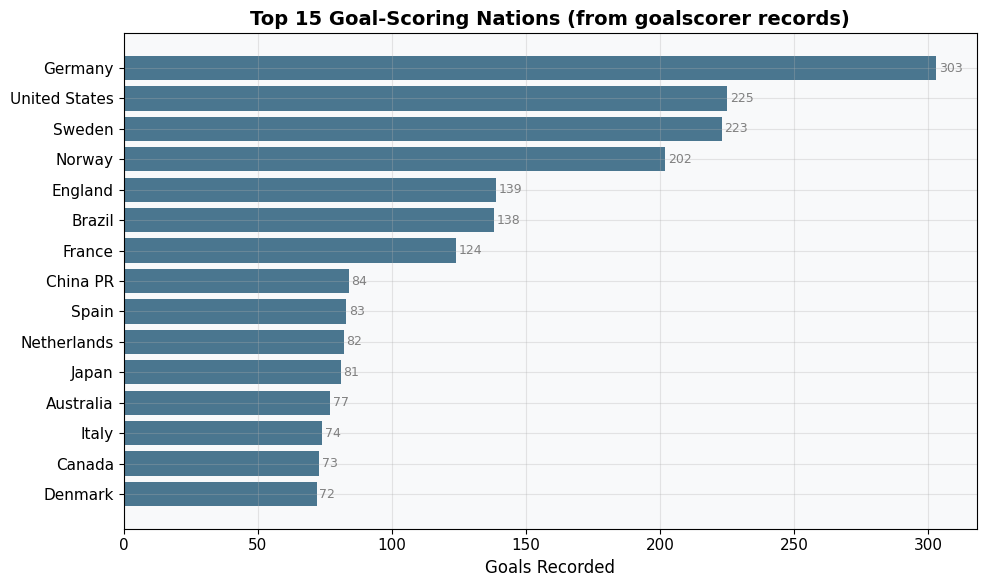

In [18]:
team_goals = goals_clean.groupby('team').size().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(team_goals.index[::-1], team_goals.values[::-1], color=ACCENT2, alpha=0.85)
for i, v in enumerate(team_goals.values[::-1]):
    ax.text(v + 1, i, str(v), va='center', fontsize=9, color='gray')
ax.set_title('Top 15 Goal-Scoring Nations (from goalscorer records)', fontweight='bold')
ax.set_xlabel('Goals Recorded')
plt.tight_layout()
plt.show()


---
## 6. Penalty Shootout Analysis

With 134 shootout records, we can analyze which teams thrive under pressure.

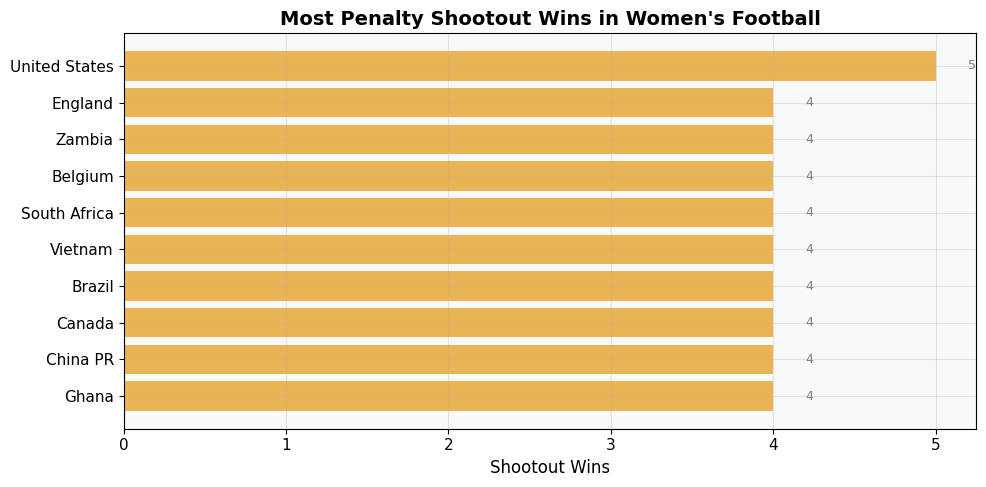

Total shootouts: 134
Most shootouts in a year: 19 (2025)
First shooter win rate: 60.5% (n=38)


In [19]:
# Most shootout wins
sh_wins = sh.groupby('winner').size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sh_wins.index[::-1], sh_wins.values[::-1], color=ACCENT3, alpha=0.85)
for i, v in enumerate(sh_wins.values[::-1]):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=9, color='gray')
ax.set_title('Most Penalty Shootout Wins in Women\'s Football', fontweight='bold')
ax.set_xlabel('Shootout Wins')
plt.tight_layout()
plt.show()

# Shootout frequency over time
sh['year'] = sh['date'].dt.year
sh_year = sh.groupby('year').size()
print(f'Total shootouts: {len(sh)}')
print(f'Most shootouts in a year: {sh_year.max()} ({sh_year.idxmax()})')

# First shooter advantage
first = sh.dropna(subset=['first_shooter'])
first['first_won'] = first['winner'] == first['first_shooter']
if len(first) > 0:
    pct = first['first_won'].mean() * 100
    print(f'First shooter win rate: {pct:.1f}% (n={len(first)})')


---
## 7. The Economics: Prize Money, Attendance & Revenue

### 7.1 World Cup Growth

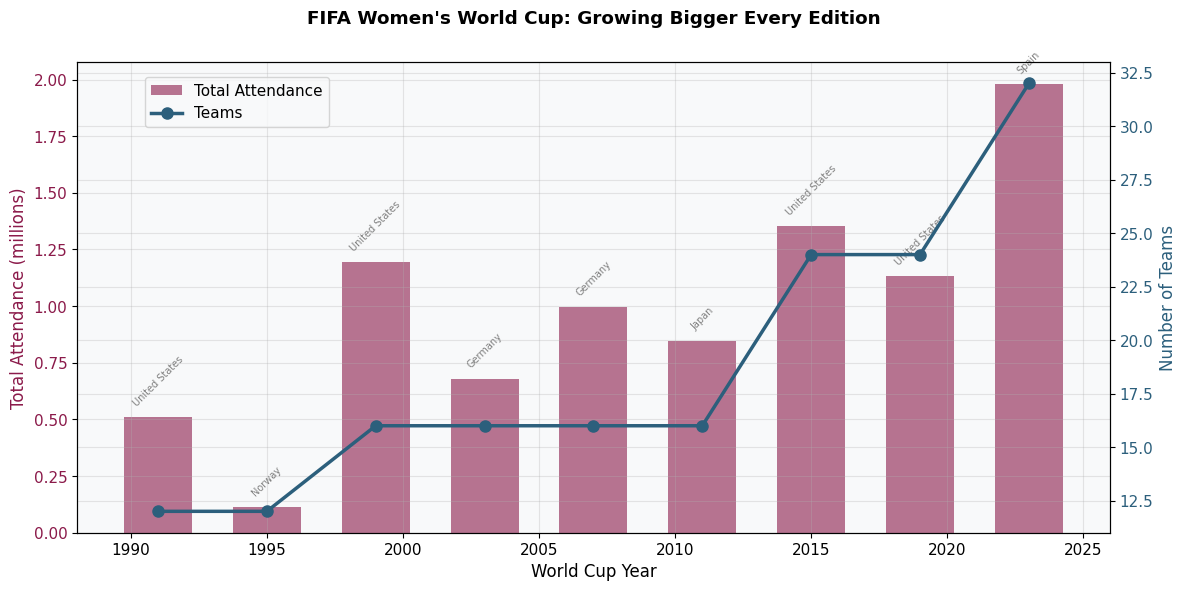

In [20]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_wc['year'], df_wc['attendance']/1e6, color=ACCENT, alpha=0.6, width=2.5, label='Total Attendance')
ax1.set_xlabel('World Cup Year')
ax1.set_ylabel('Total Attendance (millions)', color=ACCENT)
ax1.tick_params(axis='y', labelcolor=ACCENT)

ax2 = ax1.twinx()
ax2.plot(df_wc['year'], df_wc['teams'], 'o-', color=ACCENT2, linewidth=2.5, markersize=8, label='Teams')
ax2.set_ylabel('Number of Teams', color=ACCENT2)
ax2.tick_params(axis='y', labelcolor=ACCENT2)

for _, row in df_wc.iterrows():
    ax1.text(row['year'], row['attendance']/1e6 + 0.05, row['winner'],
             ha='center', fontsize=7, rotation=45, color='gray')

fig.suptitle("FIFA Women's World Cup: Growing Bigger Every Edition", fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


### 7.2 Prize Money: Men vs Women

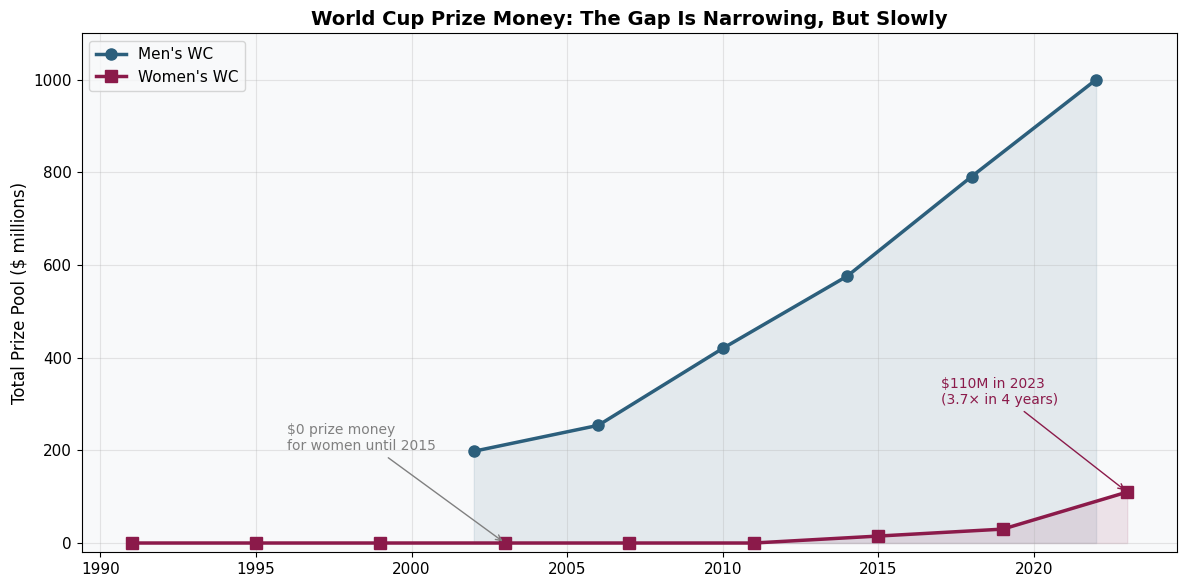

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_prize_men['year'], df_prize_men['prize_m'], 'o-', color=ACCENT2, linewidth=2.5, markersize=8, label="Men's WC")
ax.plot(df_prize_women['year'], df_prize_women['prize_m'], 's-', color=ACCENT, linewidth=2.5, markersize=8, label="Women's WC")
ax.fill_between(df_prize_men['year'], df_prize_men['prize_m'], alpha=0.1, color=ACCENT2)
ax.fill_between(df_prize_women['year'], df_prize_women['prize_m'], alpha=0.1, color=ACCENT)

ax.annotate('$0 prize money\nfor women until 2015', xy=(2003,0), xytext=(1996,200),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'), color='gray')
ax.annotate('$110M in 2023\n(3.7× in 4 years)', xy=(2023,110), xytext=(2017,300),
            fontsize=10, arrowprops=dict(arrowstyle='->', color=ACCENT), color=ACCENT)

ax.set_title('World Cup Prize Money: The Gap Is Narrowing, But Slowly', fontweight='bold')
ax.set_ylabel('Total Prize Pool ($ millions)')
ax.legend(fontsize=11)
ax.set_ylim(-20, 1100)
plt.tight_layout()
plt.show()


### 7.3 WSL Attendance Growth

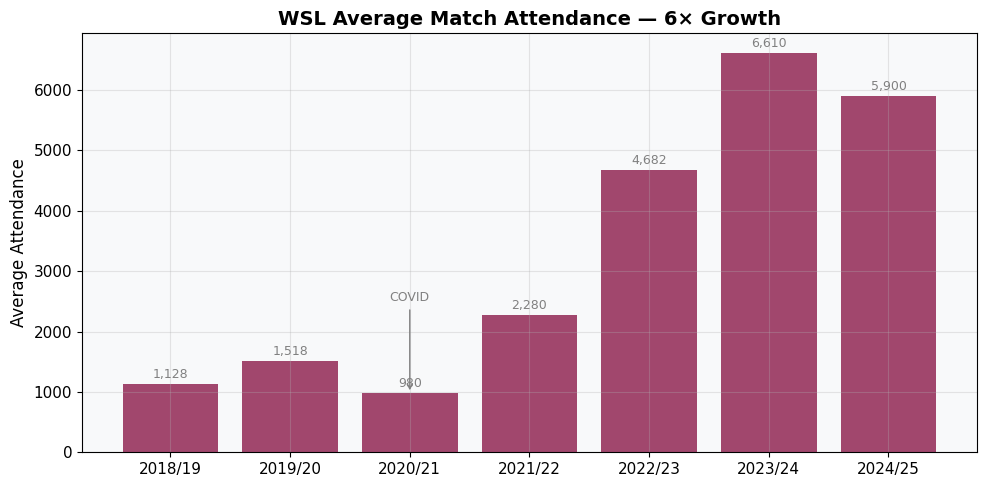

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_wsl['season'], df_wsl['avg_attendance'], color=ACCENT, alpha=0.8)
ax.annotate('COVID', xy=(2, 980), xytext=(2, 2500), textcoords='data',
            ha='center', fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'), color='gray')
for bar, val in zip(bars, df_wsl['avg_attendance']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}', ha='center', fontsize=9, color='gray')
ax.set_title('WSL Average Match Attendance — 6× Growth', fontweight='bold')
ax.set_ylabel('Average Attendance')
plt.tight_layout()
plt.show()


### 7.4 Attendance vs Prize Money Bubble Chart

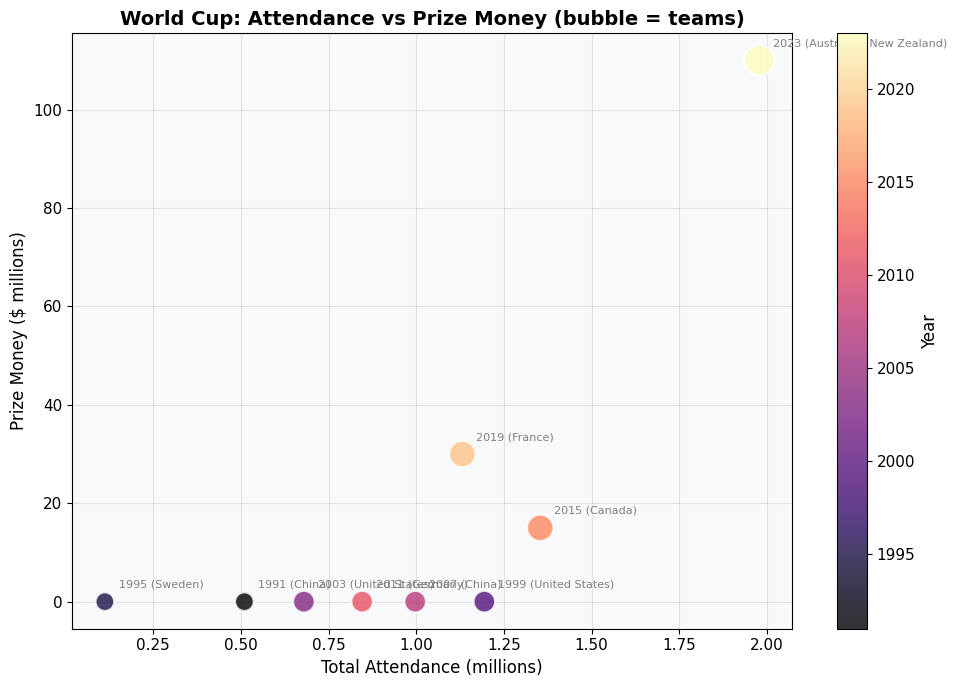

In [23]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df_wc['attendance']/1e6, df_wc['prize_money_usd']/1e6,
                     s=df_wc['teams']*15, c=df_wc['year'], cmap='magma',
                     alpha=0.8, edgecolors='white', linewidth=1.5, zorder=3)
for _, row in df_wc.iterrows():
    ax.annotate(f"{row['year']} ({row['host']})",
                xy=(row['attendance']/1e6, row['prize_money_usd']/1e6),
                xytext=(10,10), textcoords='offset points', fontsize=8, color='gray')
ax.set_title('World Cup: Attendance vs Prize Money (bubble = teams)', fontweight='bold')
ax.set_xlabel('Total Attendance (millions)')
ax.set_ylabel('Prize Money ($ millions)')
plt.colorbar(scatter, label='Year')
plt.tight_layout()
plt.show()


---
## 8. Summary Statistics

In [24]:
total_teams = len(set(df.home_team) | set(df.away_team))

print('=' * 60)
print('  KEY STATISTICS — WOMEN\'S INTERNATIONAL FOOTBALL')
print('=' * 60)
print(f'  Total matches:              {len(df):,}')
print(f'  Total unique teams:         {total_teams}')
print(f'  Date range:                 {df.year.min()}-{df.year.max()}')
print(f'  Avg goals/match (all):      {df.total_goals.mean():.2f}')
print(f'  Avg goals/match (pre-96):   {df[df.year<=1995].total_goals.mean():.2f}')
print(f'  Avg goals/match (2015+):    {df[df.year>=2015].total_goals.mean():.2f}')
print(f'  Most wins:                  {total_wins.idxmax()} ({int(total_wins.max())})')
print(f'  Unique goalscorers:         {goals_clean.scorer.nunique():,}')
print(f'  Top scorer:                 {top_scorers.index[0]} ({top_scorers.values[0]} goals)')
print(f'  Penalty shootouts:          {len(sh)}')
print(f'  World Cup editions:         {len(df_wc)}')
print(f'  WC prize money:             $0 (1991) → $110M (2023)')
print(f'  WC attendance:              510K (1991) → 1.98M (2023)')
print(f'  WC teams:                   12 (1991) → 32 (2023)')
print('=' * 60)


  KEY STATISTICS — WOMEN'S INTERNATIONAL FOOTBALL
  Total matches:              11,177
  Total unique teams:         247
  Date range:                 1956-2025
  Avg goals/match (all):      3.72
  Avg goals/match (pre-96):   3.78
  Avg goals/match (2015+):    3.51
  Most wins:                  United States (465)
  Unique goalscorers:         995
  Top scorer:                 Birgit Prinz (34 goals)
  Penalty shootouts:          134
  World Cup editions:         9
  WC prize money:             $0 (1991) → $110M (2023)
  WC attendance:              510K (1991) → 1.98M (2023)
  WC teams:                   12 (1991) → 32 (2023)


---
## 9. Key Takeaways for Visualization Design

Our EDA reveals several compelling stories to guide our final visualization:

1. **Exponential growth** — From ~10 matches/year to 300+, from 8 teams to 247. An **animated world map** showing nations joining the women's football landscape over time will be our opening visual.

2. **Maturing competitiveness** — Declining goals per match, converging regional dominance. **Small multiples and line charts** will illustrate this trajectory.

3. **The economic revolution** — Prize money, attendance, and revenue are exploding, yet remain a fraction of men's football. **Side-by-side comparisons** will powerfully convey both progress and the gap.

4. **Individual stars** — Birgit Prinz, Marta, Abby Wambach — the goalscorer data lets us build **player profile cards** and **timeline visualizations** of all-time greats.

5. **Late-game drama** — Goals cluster in the second half; shootouts have fascinating patterns. **Minute-by-minute visualizations** will engage the football-savvy audience.

6. **Geographic shift** — Africa, Asia, and South America are catching up. A **choropleth with time slider** will tell this story.

7. **On-pitch tactics** — StatsBomb event data (to integrate in Milestone 2) will add pass maps, shot heatmaps, and pressing visualizations from the 2019 and 2023 World Cups.

---

*Data sources: Kaggle (Women's International Football Results, Goalscorers, Shootouts), FIFA.com, Wikipedia, Deloitte Football Money League, StatsBomb Open Data*